In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("/content/Income_expense_data.csv")

In [3]:
#print data
df.head(5)

,REF_DATE,GEO,Statistic,Before-tax household income quintile,"Household expenditures, summary-level categories",UOM,COORDINATE,Expense,Family type,Age of older adult,Family income,Income
0,2010,Province 1,Average expenditure per household,All quintiles,Total expenditure,Dollars,C1,72075.0,Couple families,Total all ages,All income groups,7989380.0
1,2010,Province 1,Average expenditure per household,All quintiles,Food purchased from stores,Dollars,C2,5709.0,Couple families,Total all ages,"Under $10,000",189700.0
2,2010,Province 1,Average expenditure per household,All quintiles,Food purchased from restaurants,Dollars,C3,2141.0,Couple families,Total all ages,"$10,000 and over",7799670.0
3,2010,Province 1,Average expenditure per household,All quintiles,Shelter,Dollars,C4,15020.0,Couple families,Total all ages,"$15,000 and over",7695970.0
4,2010,Province 1,Average expenditure per household,All quintiles,Principal accommodation,Dollars,C5,13586.0,Couple families,Total all ages,"$20,000 and over",7552050.0


In [4]:
df.info()
#info() function gives you the summary of the data.
#by looking the data we get to know that their are total 12 columns and 13260 rows, out of 3 numerical rows.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6271 entries, 0 to 6270
Data columns (total 12 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   REF_DATE                                          6271 non-null   int64  
 1   GEO                                               6271 non-null   object 
 2   Statistic                                         6271 non-null   object 
 3   Before-tax household income quintile              6271 non-null   object 
 4   Household expenditures, summary-level categories  6271 non-null   object 
 5   UOM                                               6271 non-null   object 
 6   COORDINATE                                        6270 non-null   object 
 7   Expense                                           6162 non-null   float64
 8   Family type                                       6270 non-null   object 
 9   Age of older adult 

**In column (Expense and income) the null value is presented**

In [5]:
df.describe()

,REF_DATE,Expense,Income
count,6271.000000,6162.000000,6.268000e+03
mean,2011.885505,8834.232068,1.904370e+05
std,1.368464,19269.315386,7.682782e+05
min,2010.000000,65.000000,2.000000e+01
25%,2011.000000,1418.500000,4.650000e+03
50%,2012.000000,2967.000000,1.575500e+04
75%,2013.000000,7827.500000,4.495750e+04
max,2014.000000,198036.000000,8.382120e+06


In [6]:
#we will use Fillna method to fill the null columns.
df['Expense'] = df['Expense'].fillna(int(df['Expense'].mean()))

df['Income'] = df['Income'].fillna(int(df['Income'].mean()))
print (f"Successfully inserted the null value!!{df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6271 entries, 0 to 6270
Data columns (total 12 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   REF_DATE                                          6271 non-null   int64  
 1   GEO                                               6271 non-null   object 
 2   Statistic                                         6271 non-null   object 
 3   Before-tax household income quintile              6271 non-null   object 
 4   Household expenditures, summary-level categories  6271 non-null   object 
 5   UOM                                               6271 non-null   object 
 6   COORDINATE                                        6270 non-null   object 
 7   Expense                                           6271 non-null   float64
 8   Family type                                       6270 non-null   object 
 9   Age of older adult 

In [8]:
#Finding the max income with family type.
max_income = df.groupby("Family type")[["Income"]].max()
print(max_income)

                    Income
Family type               
Couple families  8382120.0


2. Family Type Spending Pattern

Questions:

Do couples spend more than singles?
Do families with children have higher expenses?


In [12]:
family_spending = df.groupby("Family type")[["Expense"]].mean()
print(family_spending)

                    Expense
Family type                
Couple families  8834.22807


3. Geographic Analysis

Questions:

Which region has highest household expenditure?
Which region has highest income?


In [14]:
GEO = df.groupby("GEO")[["Expense","Income"]].max().sort_values(by = "Expense", ascending= False)
print(GEO)

              Expense     Income
GEO                             
Province 12  198036.0   101650.0
Province 9   180843.0  1930260.0
Province 8   170973.0   113240.0
Province 1   161771.0  8382120.0
Province 3   157547.0   135000.0
Province 11  151138.0   188880.0
Province 13  147318.0   190437.0
Province 5   142800.0   219920.0
Province 10  142218.0   190437.0
Province 2   141248.0   135120.0
Province 7   140931.0   187580.0
Province 6   130321.0   119370.0
Province 4   122988.0   100260.0


4. Expense Category Analysis

Questions:

What categories consume most money?
Food
Housing
Transportation
Education

In [15]:
Expense_category = df.groupby("Household expenditures, summary-level categories")[["Expense"]].sum()
print(Expense_category)

                                                       Expense
Household expenditures, summary-level categories              
Clothing and accessories                             1237202.0
Communications                                        711374.0
Food purchased from restaurants                       774333.0
Food purchased from stores                           2082103.0
Household appliances                                  375704.0
Household equipment                                   445154.0
Household furnishings                                 380237.0
Household furnishings and equipment                   751151.0
Household operations                                 1525743.0
Other accommodation                                   869899.0
Owned living quarters                                2788245.0
Principal accommodation                              4773083.0
Rented living quarters                               1189955.0
Shelter                                              52

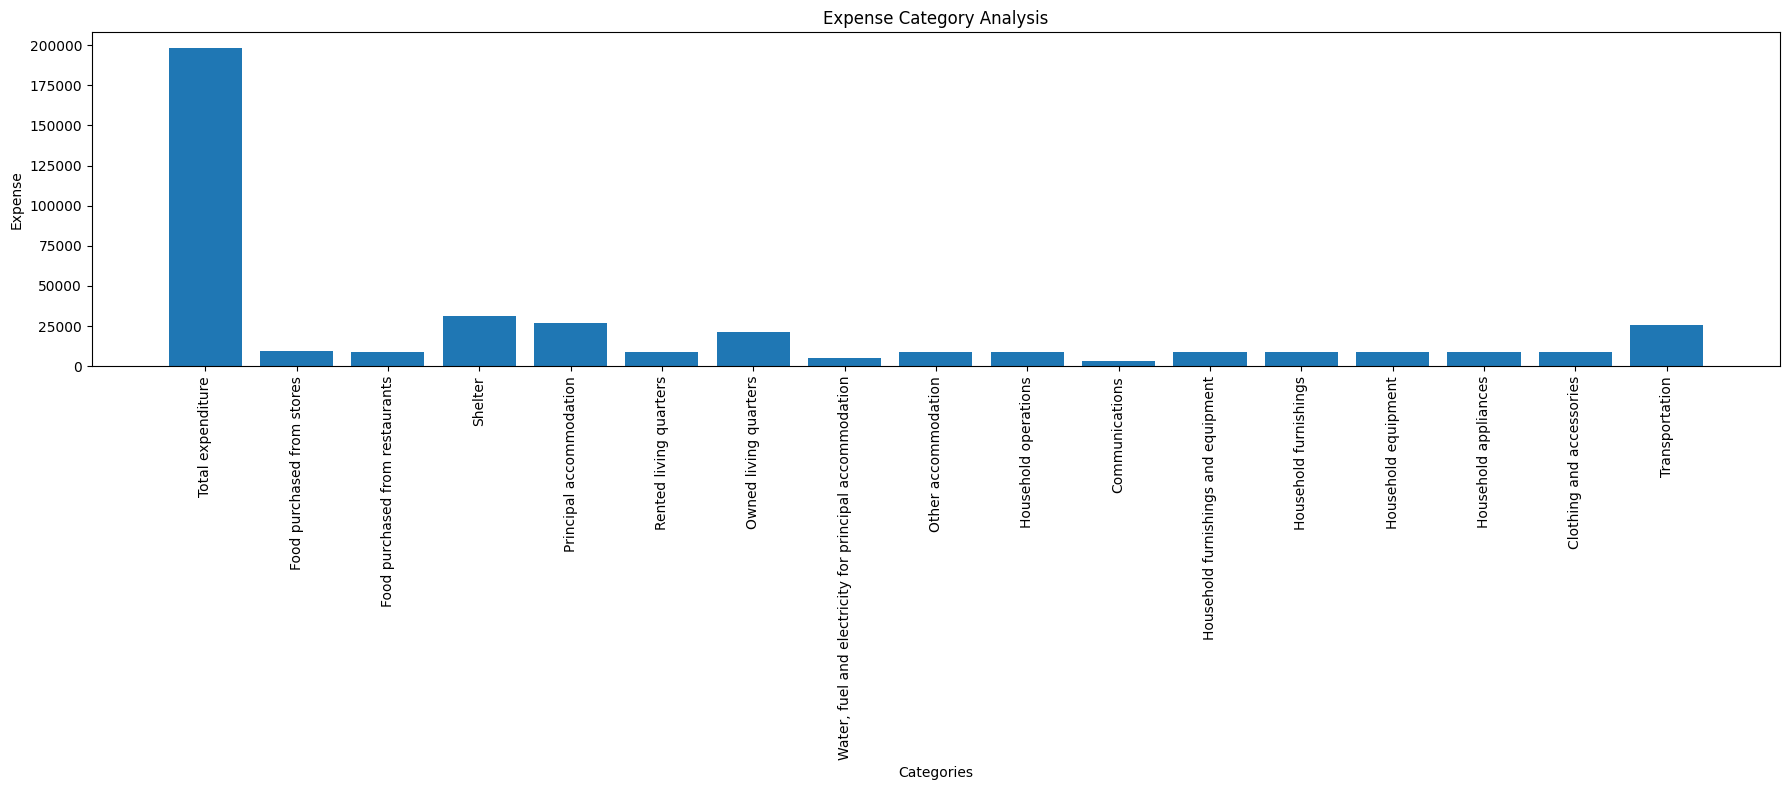

In [24]:
plt.figure(figsize=(18, 8))

plt.bar(df["Household expenditures, summary-level categories"], df["Expense"])

plt.title("Expense Category Analysis")
plt.xlabel("Categories")
plt.ylabel("Expense")

plt.xticks(rotation=90)   # Rotate labels
plt.tight_layout()

plt.show()

In [26]:
Expense_category = df.groupby("Household expenditures, summary-level categories")[["Expense"]].mean().sort_values(by = "Expense", ascending= False)
print(Expense_category)

                                                         Expense
Household expenditures, summary-level categories                
Total expenditure                                   73036.831978
Shelter                                             14308.539295
Principal accommodation                             12935.184282
Transportation                                      11677.739130
Owned living quarters                                7556.219512
Food purchased from stores                           5642.555556
Household operations                                 4134.804878
Clothing and accessories                             3361.961957
Rented living quarters                               3224.810298
Water, fuel and electricity for principal accom...   2621.710027
Other accommodation                                  2357.449864
Food purchased from restaurants                      2098.463415
Household furnishings and equipment                  2035.639566
Communications           

5. Income Quintile Comparison

Questions:

Lowest income group spends most on which category?
Highest income group spends most on which category?

In [31]:
quintile_table = pd.pivot_table(
    df,
    values="Expense",
    index="Before-tax household income quintile",
    columns="Household expenditures, summary-level categories",
    aggfunc="sum",
    fill_value=0
)

quintile_table

"Household expenditures, summary-level categories",Clothing and accessories,Communications,Food purchased from restaurants,Food purchased from stores,Household appliances,Household equipment,Household furnishings,Household furnishings and equipment,Household operations,Other accommodation,Owned living quarters,Principal accommodation,Rented living quarters,Shelter,Total expenditure,Transportation,"Water, fuel and electricity for principal accommodation"
Before-tax household income quintile,,,,,,,,,,,,,,,,,
All quintiles,208639.0,119876.0,129275.0,351220.0,27812.0,65493.0,52906.0,125518.0,257064.0,85603.0,469063.0,803303.0,171530.0,888902.0,4545173.0,725280.0,162709.0
Fourth quintile,242532.0,136863.0,152424.0,401690.0,42582.0,87128.0,57500.0,145214.0,296600.0,87399.0,617494.0,916078.0,121323.0,1003479.0,5263787.0,882224.0,185361.0
Highest quintile,374944.0,160824.0,223012.0,499376.0,78341.0,110686.0,98151.0,222320.0,406665.0,224603.0,860503.0,1146362.0,218407.0,1354134.0,8687558.0,1222403.0,224657.0
Lowest quintile,89878.0,73685.0,65163.0,204788.0,106826.0,77670.0,75181.0,56896.0,136103.0,266806.0,152325.0,522515.0,279475.0,546204.0,1830330.0,300865.0,97932.0
Second quintile,134168.0,99934.0,86935.0,288285.0,69784.0,44120.0,34688.0,82792.0,188707.0,120075.0,267047.0,630458.0,226169.0,669771.0,2776931.0,486742.0,137244.0
Third quintile,187041.0,120192.0,117524.0,336744.0,50359.0,60057.0,61811.0,118411.0,240604.0,85413.0,421813.0,754367.0,173051.0,817361.0,3846812.0,679894.0,159508.0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6271 entries, 0 to 6270
Data columns (total 12 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   REF_DATE                                          6271 non-null   int64  
 1   GEO                                               6271 non-null   object 
 2   Statistic                                         6271 non-null   object 
 3   Before-tax household income quintile              6271 non-null   object 
 4   Household expenditures, summary-level categories  6271 non-null   object 
 5   UOM                                               6271 non-null   object 
 6   COORDINATE                                        6270 non-null   object 
 7   Expense                                           6271 non-null   float64
 8   Family type                                       6270 non-null   object 
 9   Age of older adult 

Age-wise Spending Behaviour

In [32]:
age_spending = df.groupby("Age of older adult")[["Expense"]].mean()

age_spending

,Expense
Age of older adult,
0 to 24 years,4632.487666
25 to 34 years,6027.607992
35 to 44 years,7937.282546
45 to 54 years,10260.055931
55 to 64 years,15538.038573
Total all ages,8718.563567


In [33]:
age_income_expense = df.groupby("Age of older adult")[["Income","Expense"]].mean()

age_income_expense

,Income,Expense
Age of older adult,,
0 to 24 years,8768.371917,4632.487666
25 to 34 years,83006.993340,6027.607992
35 to 44 years,133006.923819,7937.282546
45 to 54 years,157024.156220,10260.055931
55 to 64 years,140524.609450,15538.038573
Total all ages,617714.981025,8718.563567


In [38]:
df["Savings"] = df["Income"] - df["Expense"]
print(df["Savings"])

0       7917305.0
1        183991.0
2       7797529.0
3       7680950.0
4       7538464.0
          ...    
6266       2699.0
6267       2632.0
6268       2883.0
6269       2180.0
6270     181603.0
Name: Savings, Length: 6271, dtype: float64


In [39]:
saving_quintile = df.groupby(
    "Before-tax household income quintile"
)[["Savings"]].mean()

saving_quintile

,Savings
Before-tax household income quintile,
All quintiles,608996.417457
Fourth quintile,146764.100289
Highest quintile,124986.570878
Lowest quintile,4135.884250
Second quintile,77078.837452
Third quintile,125069.641273


In [40]:
saving_quintile = df.groupby(
    "Before-tax household income quintile"
)[["Savings"]].max()

saving_quintile

,Savings
Before-tax household income quintile,
All quintiles,8301393.0
Fourth quintile,1847034.0
Highest quintile,1706437.0
Lowest quintile,189084.0
Second quintile,1075091.0
Third quintile,1602847.0


In [41]:
saving_family = df.groupby("Family type")[["Savings"]].mean()

saving_family

,Savings
Family type,
Couple families,181602.782137


In [42]:
top_region = df.groupby("GEO")[["Expense"]].sum().sort_values(
    by="Expense",
    ascending=False
).head(10)

top_region

,Expense
GEO,
Province 9,5247521.0
Province 8,5027196.0
Province 1,4683263.0
Province 12,4581608.0
Province 3,4280210.0
Province 5,4150778.0
Province 4,4137259.0
Province 2,4028317.0
Province 7,3999020.0
